# Прогнозирование стоимости автомобилей с использованием линейных моделей

В данном проекте исследуется задача регрессии для предсказания стоимости автомобилей на основе числовых и категориальных признаков с использованием линейных моделей машинного обучения.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.model_selection import train_test_split

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, SGDRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
import warnings
warnings.filterwarnings('ignore')

## Обзор данных

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/dayekb/mpti_ml/main/data/cars_moldova_no_dup_no_outliers.csv', delimiter = ',')
df.head()

,Make,Model,Year,Style,Distance,Engine_capacity(cm3),Fuel_type,Transmission,Price(euro)
0,Toyota,Prius,2011,Hatchback,195000.0,1800.0,Hybrid,Automatic,7750.0
1,Renault,Grand Scenic,2014,Universal,135000.0,1500.0,Diesel,Manual,8550.0
2,Renault,Laguna,2012,Universal,110000.0,1500.0,Diesel,Manual,6550.0
3,Opel,Astra,2006,Universal,200000.0,1600.0,Metan/Propan,Manual,4100.0
4,Mercedes,Vito,2000,Microvan,300000.0,2200.0,Diesel,Manual,3490.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32485 entries, 0 to 32484
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Make                  32485 non-null  object 
 1   Model                 32485 non-null  object 
 2   Year                  32485 non-null  int64  
 3   Style                 32485 non-null  object 
 4   Distance              32485 non-null  float64
 5   Engine_capacity(cm3)  32485 non-null  float64
 6   Fuel_type             32485 non-null  object 
 7   Transmission          32485 non-null  object 
 8   Price(euro)           32485 non-null  float64
dtypes: float64(3), int64(1), object(5)
memory usage: 2.2+ MB


In [5]:
num = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat = df.select_dtypes(include=['object']).columns.tolist()

In [6]:
df[num].describe()

,Year,Distance,Engine_capacity(cm3),Price(euro)
count,32485.000000,32485.000000,32485.000000,32485.000000
mean,2008.222964,179214.511929,1834.547391,8962.558535
std,7.212853,91554.954674,625.236731,7839.471389
min,1971.000000,1.000000,0.000000,200.000000
25%,2004.000000,122000.000000,1497.000000,3500.000000
50%,2009.000000,180000.000000,1800.000000,6690.000000
75%,2014.000000,235000.000000,2000.000000,11999.000000
max,2021.000000,500000.000000,5000.000000,50000.000000


In [7]:
df[cat].describe()

,Make,Model,Style,Fuel_type,Transmission
count,32485,32485,32485,32485,32485
unique,79,781,12,6,2
top,Volkswagen,E Class,Sedan,Diesel,Manual
freq,3441,1098,9832,15213,17767


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isna().sum()

,0
Make,0
Model,0
Year,0
Style,0
Distance,0
Engine_capacity(cm3),0
Fuel_type,0
Transmission,0
Price(euro),0


## Работа с данными

### Числовые признаки

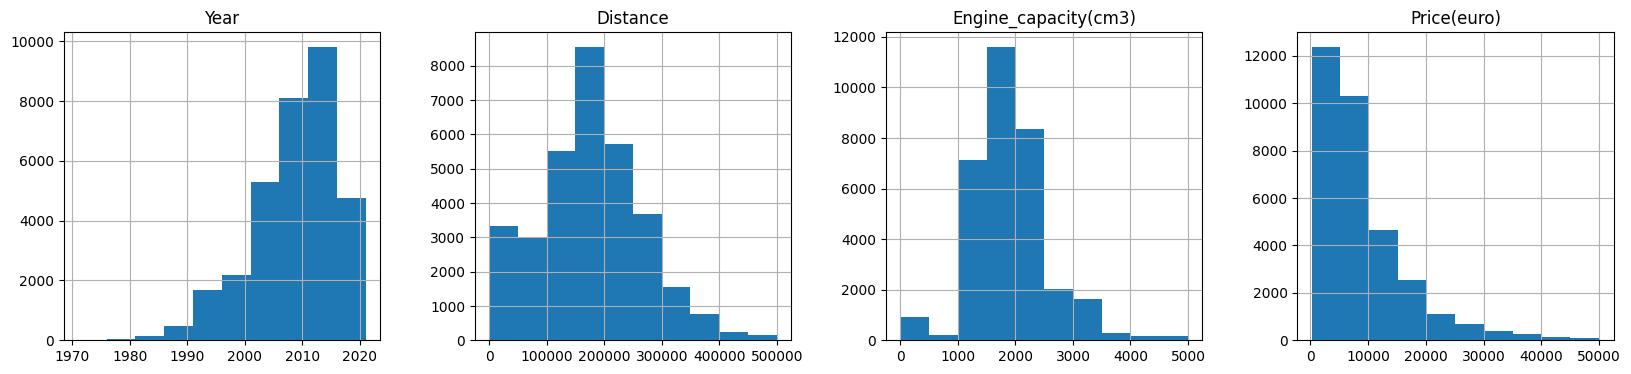

In [10]:
fig, axs = plt.subplots(1,4,figsize=(20,  4))

df.hist(column = num, ax = axs);

In [11]:
print("Year < 1990:", (df['Year'] < 1990).mean())
print("Engine < 800:", (df['Engine_capacity(cm3)'] < 800).mean())
print("Price < 500:", (df['Price(euro)'] < 500).mean())

Year < 1990: 0.015761120517161768
Engine < 800: 0.029367400338617823
Price < 500: 0.0025858088348468524


In [12]:
df[df['Engine_capacity(cm3)'] < 800].head(5)

,Make,Model,Year,Style,Distance,Engine_capacity(cm3),Fuel_type,Transmission,Price(euro)
8,BMW,5 Series,2004,Sedan,325000.0,300.0,Diesel,Manual,3400.0
21,Tesla,Model S,2013,Hatchback,113000.0,367.0,Electric,Automatic,27000.0
34,Volkswagen,Touran,2004,Minivan,280000.0,200.0,Diesel,Automatic,5300.0
135,Hyundai,Tucson,2014,Crossover,120000.0,200.0,Metan/Propan,Automatic,12000.0
185,Mazda,626,1994,Sedan,300000.0,200.0,Metan/Propan,Manual,18000.0


In [13]:
df = df[
    (df['Year'] >= 1990) &
    (df['Engine_capacity(cm3)'] >= 800) &
    (df['Price(euro)'] >= 500)
]

Обработка аномальных значений

В ходе анализа распределения числовых признаков были выявлены аномальные значения, способные негативно повлиять на обучение модели.

Были приняты следующие решения:

1. **Объём двигателя < 800 см³**  
   В данных присутствуют нереалистичные значения (например, автомобили BMW с объёмом двигателя 200–300 см³), что, вероятно, связано с ошибками ввода данных. Такие наблюдения были удалены.

2. **Цена < 500 евро**  
   Доля таких значений составляет менее 0.3% от выборки. Они представляют собой либо ошибки, либо неликвидные автомобили и не отражают типичный рынок. Данные наблюдения были исключены.

3. **Год выпуска < 1990**  
   Данные составляют около 1.5% выборки. Старые автомобили могут иметь существенно отличающиеся характеристики и структуру цены, что может вносить шум в модель. Эти наблюдения были удалены.

Таким образом, были удалены редкие и/или некорректные значения, способные исказить обучение модели.

In [14]:
df['car_age'] = 2021 - df['Year']
df = df.drop(['Year'], axis=1)

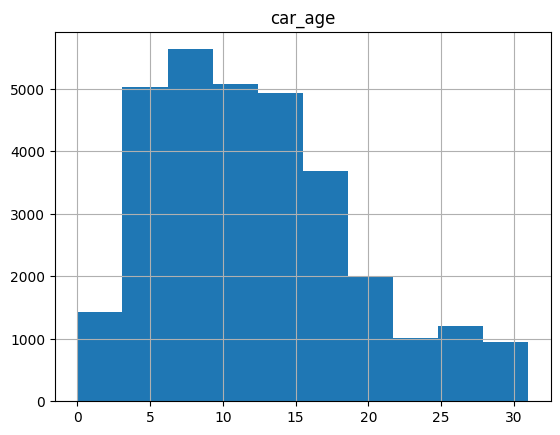

In [15]:
df.hist(column = 'car_age');

Создадим новый признак `car_age`, отражающий возраст автомобиля:

\[
car\_age = 2021 - Year
\]

Данное преобразование было выполнено по следующим причинам:
- возраст автомобиля имеет более интерпретируемую и линейную связь с ценой;
- линейной модели проще обучаться на признаке возраста, чем на абсолютном значении года;
- признак `Year` и `car_age` являются линейно зависимыми, поэтому для избежания мультиколлинеарности исходный признак `Year` был удалён.

Таким образом, признак года выпуска был заменён на более информативное представление — возраст автомобиля.

## Категориальные признаки

In [16]:
for col in cat:
    print(col, df[col].nunique())

Make 78
Model 751
Style 12
Fuel_type 6
Transmission 2


In [17]:
for col in cat:
    print(f"\n{col}")
    print(df[col].value_counts().head(10))


Make
Make
Volkswagen    3297
Toyota        3033
Mercedes      2810
BMW           2408
Renault       2351
Opel          1793
Skoda         1721
Audi          1435
Dacia         1344
Ford          1301
Name: count, dtype: int64

Model
Model
E Class     1053
5 Series     966
Passat       824
Megane       812
Astra        794
Golf         748
Octavia      591
Auris        580
Qashqai      499
Superb       481
Name: count, dtype: int64

Style
Style
Sedan        9182
Universal    5766
Hatchback    5112
Crossover    3942
SUV          2888
Minivan      2584
Coupe         531
Microvan      404
Combi         327
Cabriolet     124
Name: count, dtype: int64

Fuel_type
Fuel_type
Diesel            14857
Petrol            10547
Metan/Propan       3333
Hybrid             1815
Plug-in Hybrid      423
Electric             22
Name: count, dtype: int64

Transmission
Transmission
Manual       16817
Automatic    14180
Name: count, dtype: int64


In [18]:
for col in cat:
    print(f"\n{col}")
    print(df[col].value_counts(normalize=True).head(10))


Make
Make
Volkswagen    0.106365
Toyota        0.097848
Mercedes      0.090654
BMW           0.077685
Renault       0.075846
Opel          0.057844
Skoda         0.055522
Audi          0.046295
Dacia         0.043359
Ford          0.041972
Name: proportion, dtype: float64

Model
Model
E Class     0.033971
5 Series    0.031164
Passat      0.026583
Megane      0.026196
Astra       0.025615
Golf        0.024131
Octavia     0.019066
Auris       0.018711
Qashqai     0.016098
Superb      0.015518
Name: proportion, dtype: float64

Style
Style
Sedan        0.296222
Universal    0.186018
Hatchback    0.164919
Crossover    0.127174
SUV          0.093170
Minivan      0.083363
Coupe        0.017131
Microvan     0.013034
Combi        0.010549
Cabriolet    0.004000
Name: proportion, dtype: float64

Fuel_type
Fuel_type
Diesel            0.479304
Petrol            0.340259
Metan/Propan      0.107527
Hybrid            0.058554
Plug-in Hybrid    0.013646
Electric          0.000710
Name: proportion, dty

В ходе анализа категориальных признаков была оценена их кардинальность и распределение значений.

Были приняты следующие решения:

1. **Признак Model**  
   Содержит большое количество уникальных значений (более 700), что приводит к высокой разреженности при one-hot кодировании и увеличивает риск переобучения линейной модели. В связи с этим признак был исключён из дальнейшего анализа.

2. **Признак Make**  
   Содержит значительное количество категорий (78), при этом наблюдается длинный хвост редких значений. Для снижения размерности и шума редкие категории будут объединены в отдельную группу.

3. **Признак Style**  
   Имеет умеренную кардинальность (12 категорий) и равномерное распределение. Признак сохраняется без значительных изменений.

4. **Признак Fuel_type**  
   Содержит редкие категории (например, Electric и Plug-in Hybrid), которые будут объединены в группу редких значений.

5. **Признак Transmission**  
   Содержит всего две категории и не требует дополнительной обработки.

Таким образом, для категориальных признаков будет применено объединение редких категорий с последующим one-hot кодированием.

### Обработка признаков

In [19]:
X = df.drop(['Price(euro)', 'Model'], axis=1)
y = np.log1p(df['Price(euro)'])

In [20]:
num = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat = X.select_dtypes(include=['object', 'category']).columns.tolist()

print('num:', num)
print('cat:', cat)

num: ['Distance', 'Engine_capacity(cm3)', 'car_age']
cat: ['Make', 'Style', 'Fuel_type', 'Transmission']


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
class RareGrouper(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.01, other_value='Other'):
        self.threshold = threshold
        self.other_value = other_value
        self.freq_dict_ = {}

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        X.columns = X.columns.astype(str)

        for col in X.columns:
            freq = X[col].value_counts(normalize=True)
            self.freq_dict_[col] = freq[freq >= self.threshold].index.tolist()
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        X.columns = X.columns.astype(str)

        for col in X.columns:
            valid_categories = self.freq_dict_.get(col, [])
            X[col] = X[col].where(X[col].isin(valid_categories), self.other_value)
        return X

In [23]:
preprocessor_num = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num)
    ],
    remainder='drop'
)

In [24]:
categorical_transformer = Pipeline(steps=[
    ('rare_grouper', RareGrouper(threshold=0.01, other_value='Other')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_full = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num),
        ('cat', categorical_transformer, cat)
    ],
    remainder='drop'
)

Данные были разделены на обучающую и тестовую выборки в соотношении 80/20.

В рамках предобработки:
- числовые признаки были стандартизированы;
- категориальные признаки обработаны с помощью объединения редких категорий и one-hot кодирования.

Все этапы предобработки были реализованы в виде единого pipeline, что обеспечивает воспроизводимость и корректность эксперимента.

## Обучение моделей

Для оценки качества предсказания стоимости автомобилей были обучены несколько линейных моделей машинного обучения.

Рассматриваются два варианта признакового пространства:
- только числовые признаки (`num`);
- комбинация числовых и категориальных признаков (`num+cat`).

Это позволяет оценить вклад категориальных признаков в итоговое качество модели.

В качестве моделей были выбраны:
- LinearRegression — базовая линейная модель;
- Ridge — линейная модель с L2-регуляризацией;
- Lasso — линейная модель с L1-регуляризацией;
- SGDRegressor — линейная модель, обучаемая стохастическим градиентным спуском.

Такой набор позволяет сравнить как базовую линейную регрессию, так и её регуляризованные и оптимизационные варианты.

In [25]:
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.001, max_iter=10000),
    'SGDRegressor': SGDRegressor(random_state=42, max_iter=2000, tol=1e-3)
}

In [26]:
pipelines_num = {
    name: Pipeline(steps=[
        ('preprocessor', preprocessor_num),
        ('model', model)
    ])
    for name, model in models.items()
}

pipelines_full = {
    name: Pipeline(steps=[
        ('preprocessor', preprocessor_full),
        ('model', model)
    ])
    for name, model in models.items()
}

Для более надёжного сравнения моделей была использована 5-fold кросс-валидация.

В отличие от одного разбиения train/test, кросс-валидация позволяет:
- получить более устойчивую оценку качества;
- уменьшить зависимость результатов от конкретного разбиения данных;
- оценить разброс метрики на различных подвыборках.

В качестве метрики используется RMSE, рассчитанная в логарифмированном пространстве целевой переменной.

In [27]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for name, pipe in pipelines_num.items():
    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring='neg_root_mean_squared_error'
    )

    cv_results.append({
        'model': name,
        'feature_set': 'num',
        'cv_rmse_mean_log': -scores.mean(),
        'cv_rmse_std_log': scores.std()
    })

for name, pipe in pipelines_full.items():
    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring='neg_root_mean_squared_error'
    )

    cv_results.append({
        'model': name,
        'feature_set': 'num+cat',
        'cv_rmse_mean_log': -scores.mean(),
        'cv_rmse_std_log': scores.std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(by='cv_rmse_mean_log')
cv_results_df

,model,feature_set,cv_rmse_mean_log,cv_rmse_std_log
4,LinearRegression,num+cat,0.398497,0.007192
5,Ridge,num+cat,0.398499,0.007189
6,Lasso,num+cat,0.399589,0.006977
7,SGDRegressor,num+cat,0.403724,0.007487
0,LinearRegression,num,0.448861,0.005942
1,Ridge,num,0.448861,0.005941
2,Lasso,num,0.448867,0.005896
3,SGDRegressor,num,0.449098,0.005687


Результаты кросс-валидации показывают, что добавление категориальных признаков существенно улучшает качество модели: значение RMSE заметно снижается при переходе от набора `num` к `num+cat`.

При этом различия между линейными моделями (LinearRegression, Ridge, Lasso, SGDRegressor) оказываются минимальными и находятся в пределах статистического разброса.

Низкое значение стандартного отклонения метрики по фолдам свидетельствует о стабильности моделей и отсутствии сильной зависимости от разбиения данных.

Таким образом, основной вклад в качество модели вносит расширение признакового пространства, а не выбор конкретного алгоритма.

In [30]:
best_row = cv_results_df.iloc[0]
best_model_name = best_row['model']
best_feature_set = best_row['feature_set']

print('Best model:', best_model_name)
print('Best feature set:', best_feature_set)

Best model: LinearRegression
Best feature set: num+cat


На основе результатов кросс-валидации в качестве финальной модели была выбрана LinearRegression с полным набором признаков (`num+cat`).

Данная модель показала наилучшее среднее значение метрики при сохранении высокой интерпретируемости, что делает её удобной для анализа влияния признаков.

In [31]:
if best_feature_set == 'num':
    best_pipe = pipelines_num[best_model_name]
else:
    best_pipe = pipelines_full[best_model_name]

После выбора модели по результатам кросс-валидации она была обучена на обучающей выборке и оценена на отложенной тестовой выборке.

Это позволяет получить независимую оценку качества модели на данных, которые не использовались в процессе обучения.

In [33]:
best_pipe.fit(X_train, y_train)

y_test_pred_log = best_pipe.predict(X_test)

y_test_true = np.expm1(y_test)
y_test_pred = np.expm1(y_test_pred_log)

final_rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred))
final_mae = mean_absolute_error(y_test_true, y_test_pred)
final_r2 = r2_score(y_test_true, y_test_pred)

final_results = pd.DataFrame({
    'model': [best_model_name],
    'feature_set': [best_feature_set],
    'test_rmse': [final_rmse],
    'test_mae': [final_mae],
    'test_r2': [final_r2]
})

final_results

,model,feature_set,test_rmse,test_mae,test_r2
0,LinearRegression,num+cat,3721.528984,2111.185289,0.767444


Для более наглядной оценки качества предсказаний рассмотрим графики, позволяющие проанализировать:
- соответствие предсказанных и истинных значений;
- структуру ошибок модели;
- распределение ошибок;
- зависимость ошибки от ценового сегмента.

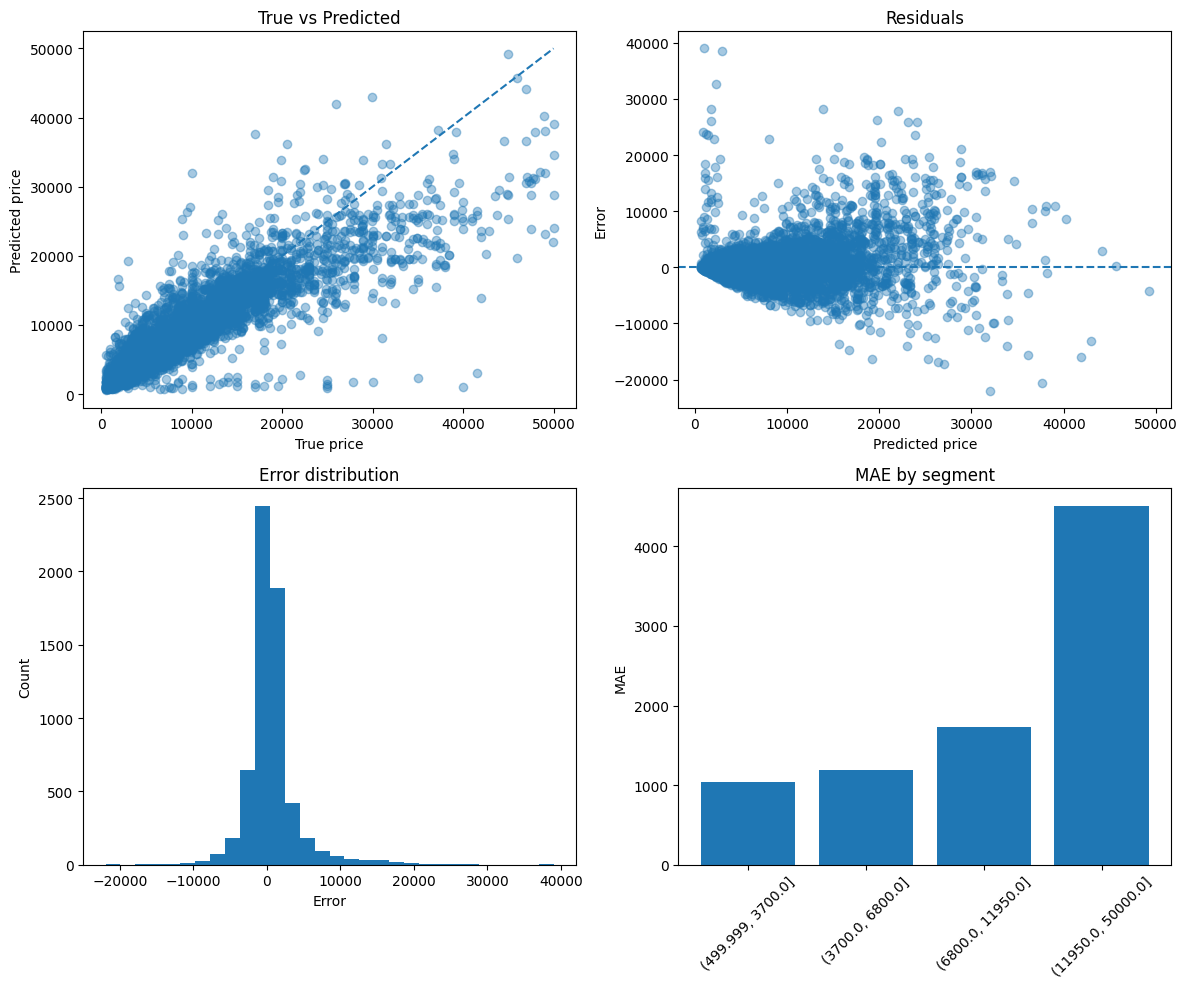

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- 1. True vs Predicted ---
axes[0, 0].scatter(y_test_true, y_test_pred, alpha=0.4)

min_val = min(y_test_true.min(), y_test_pred.min())
max_val = max(y_test_true.max(), y_test_pred.max())

axes[0, 0].plot([min_val, max_val], [min_val, max_val], linestyle='--')
axes[0, 0].set_title('True vs Predicted')
axes[0, 0].set_xlabel('True price')
axes[0, 0].set_ylabel('Predicted price')


# --- 2. Residuals ---
residuals = y_test_true - y_test_pred

axes[0, 1].scatter(y_test_pred, residuals, alpha=0.4)
axes[0, 1].axhline(0, linestyle='--')
axes[0, 1].set_title('Residuals')
axes[0, 1].set_xlabel('Predicted price')
axes[0, 1].set_ylabel('Error')


# --- 3. Error distribution ---
axes[1, 0].hist(residuals, bins=30)
axes[1, 0].set_title('Error distribution')
axes[1, 0].set_xlabel('Error')
axes[1, 0].set_ylabel('Count')


# --- 4. MAE by segment ---
error_df = pd.DataFrame({
    'true_price': y_test_true,
    'pred_price': y_test_pred,
    'abs_error': np.abs(y_test_true - y_test_pred)
})

error_df['price_bin'] = pd.qcut(error_df['true_price'], q=4, duplicates='drop')
segment_mae = error_df.groupby('price_bin', observed=False)['abs_error'].mean()

axes[1, 1].bar(range(len(segment_mae)), segment_mae.values)
axes[1, 1].set_title('MAE by segment')
axes[1, 1].set_xticks(range(len(segment_mae)))
axes[1, 1].set_xticklabels(segment_mae.index, rotation=45)
axes[1, 1].set_ylabel('MAE')

plt.tight_layout()
plt.show()

Визуальный анализ показал, что модель в целом хорошо улавливает общий тренд зависимости цены от признаков: большинство предсказаний располагается вдоль диагонали на графике `True vs Predicted`.

Однако график остатков демонстрирует увеличение разброса ошибки с ростом стоимости автомобиля. Это означает, что модель хуже справляется с предсказанием цен для дорогих объектов.

Анализ ошибки по ценовым сегментам подтверждает этот вывод: средняя абсолютная ошибка значительно возрастает в верхнем ценовом диапазоне.

Вероятной причиной является как меньшее количество дорогих автомобилей в выборке, так и более сложная и менее линейная зависимость их стоимости от признаков.

Поскольку в качестве финальной модели используется линейная регрессия, её коэффициенты можно интерпретировать как вклад соответствующих признаков в предсказание стоимости автомобиля.

Числовые признаки были стандартизированы, что позволяет корректно сравнивать их коэффициенты по масштабу. Для категориальных признаков, закодированных с помощью one-hot encoding, коэффициенты отражают влияние конкретной категории относительно базовой.

In [40]:
preprocessor = best_pipe.named_steps['preprocessor']

cat_pipeline = preprocessor.named_transformers_['cat']
ohe = cat_pipeline.named_steps['onehot']

cat_features = ohe.get_feature_names_out(cat)

num_features = num

feature_names = list(num_features) + list(cat_features)

len(feature_names), len(best_pipe.named_steps['model'].coef_)

(43, 43)

In [41]:
coefs = best_pipe.named_steps['model'].coef_

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coef': coefs
})

coef_df['abs_coef'] = coef_df['coef'].abs()
coef_df = coef_df.sort_values(by='abs_coef', ascending=False)

coef_df.head(10)

,feature,coef,abs_coef
2,car_age,-0.621557,0.621557
6,Make_Dacia,-0.329183,0.329183
13,Make_Mercedes,0.293122,0.293122
5,Make_Chevrolet,-0.283050,0.283050
4,Make_BMW,0.279564,0.279564
11,Make_Lexus,0.259399,0.259399
3,Make_Audi,0.255885,0.255885
27,Style_Crossover,0.239315,0.239315
25,Style_Combi,-0.238620,0.238620
32,Style_SUV,0.237372,0.237372


Анализ коэффициентов линейной модели показал, что наибольшее влияние на цену автомобиля оказывает возраст (`car_age`). Отрицательный коэффициент подтверждает ожидаемую зависимость: с увеличением возраста стоимость автомобиля снижается.

Среди категориальных признаков наиболее значимыми оказались марки автомобилей. Премиальные бренды (BMW, Mercedes, Audi, Lexus) имеют положительное влияние на цену, тогда как более бюджетные марки (например, Dacia) — отрицательное.

Также заметное влияние оказывает тип кузова: кроссоверы и SUV ассоциируются с более высокой стоимостью.

Таким образом, модель отражает как технические характеристики автомобиля, так и рыночные факторы, связанные с восприятием бренда.

## Выводы

В рамках проекта была решена задача предсказания стоимости автомобилей с использованием линейных моделей машинного обучения.

Показано, что ключевым фактором повышения качества модели является использование категориальных признаков: добавление таких признаков привело к существенному снижению ошибки.

При этом различия между различными линейными моделями оказались минимальными, что указывает на линейный характер зависимости и достаточность базовой модели.

Анализ ошибок выявил, что модель хуже работает на дорогих автомобилях, что связано с меньшим количеством таких наблюдений и более сложной структурой их ценообразования.

Таким образом, дальнейшее улучшение качества модели, вероятно, связано не с усложнением алгоритма, а с развитием признаков и использованием более сложных (нелинейных) моделей.